# Dynamics and Predictive Power of the Variance Risk Premium in S&P500 Options
## Part 1 - Features engineering

In [1]:
#import sys
#!{sys.executable} -m pip install yfinance

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings, glob

from utilities.clean_data import load_and_clean
from utilities.compute_IV import bs_price, implied_vol, compute_iv_surface
from utilities.ts_construction import extract_daily_metrics


In [3]:
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'DejaVu Sans',
})

# ── User settings ──────────────────────────────────────────────────────────────
DATA_FOLDER   = './data'        # folder containing all YYYY-MM-DD.csv files
TARGET_TENOR  = 30              # target tenor in days for daily metrics
WING_LOW      = -0.15           # put-wing lower bound (log-moneyness)
WING_HIGH_PUT = -0.05           # put-wing upper bound
WING_LOW_CALL =  0.05           # call-wing lower bound
WING_HIGH     =  0.15           # call-wing upper bound
RV_WINDOW     = 21              # rolling window for realized vol (trading days)

print("Libraries loaded")

Libraries loaded


## 1 · Black-Scholes pricing & implied volatility

### 1.1 Theoretical background

The **Black-Scholes** formula prices a European option under the assumptions of:
- Log-normal dynamics for the underlying: $dS = \mu S\,dt + \sigma S\,dW_t$
- Constant volatility $\sigma$, constant risk-free rate $r$, no dividends

$$C(S,K,T,r,\sigma) = S\,\Phi(d_1) - K e^{-rT}\,\Phi(d_2)$$

$$d_1 = \frac{\ln(S/K) + (r + \frac{1}{2}\sigma^2)T}{\sigma\sqrt{T}}, \quad d_2 = d_1 - \sigma\sqrt{T}$$

**Implied volatility** $\hat\sigma$ is the value of $\sigma$ that equates the model price to the observed market price:

$$\hat\sigma = \{\sigma : \text{BS}(S,K,T,\hat{r},\sigma) = C^{\text{mkt}}\}$$

where $\hat{r}$ is the **implied discount rate** extracted per (date, expiry) via put-call parity regression (see Section 2.3), rather than a fixed constant.

We solve this numerically using **Brent's method** (bracketed root-finding, guaranteed convergence).


In [4]:
# ── Quick sanity check ─────────────────────────────────────────────────────────
S_test, K_test, T_test, r_test, sig_test = 100, 100, 0.25, 0.02, 0.20
price_test = bs_price(S_test, K_test, T_test, r_test, sig_test, 'C')
iv_back    = implied_vol(price_test, S_test, K_test, T_test, r_test, 'C')
print(f"BS price (ATM call, σ=20%): {price_test:.4f}")
print(f"Recovered IV:               {iv_back*100:.4f}%  ← should be 20.0000%")
assert abs(iv_back - sig_test) < 1e-5, "IV inversion failed!"
print("Black-Scholes & IV inversion validated")


BS price (ATM call, σ=20%): 4.2322
Recovered IV:               20.0000%  ← should be 20.0000%
Black-Scholes & IV inversion validated


## 2 · Data loading & cleaning

### 2.1 Dataset
Each daily file contains all listed SPX options for that trading date.
Columns: `date`, `ask`, `bid`, `strike`, `open_interest`, `exp_date`, `type (C/P)`.
The dataset spans **253 trading days** (Jun 2017 – Jun 2018) with ~1,500 contracts/day.

### 2.2 Cleaning
1. Parse dates, compute $T = (\text{expiry} - \text{date}) / 365$
2. Compute mid price: $P^{\text{mid}} = (\text{ask} + \text{bid}) / 2$
3. Drop options with $T < 7$ days (expiry noise)
4. Drop options with relative bid-ask spread $> 50\%$ (illiquid)

### 2.3 Spot & discount factor — implicit regression on put-call parity

Instead of applying put-call parity strike by strike with a fixed risk-free rate,
we exploit the **linear structure** of put-call parity across strikes (Brenner & Galai, 1986).

For a given (date, expiry) pair:

$$C - P = B \cdot (F - K) \implies \underbrace{C-P}_{G} = \underbrace{BF}_{\text{intercept}} - \underbrace{B}_{\text{slope}} \cdot K$$

Fitting this regression across all strikes gives:

$$\hat{B} = -\hat{b}, \quad \hat{F} = \frac{\hat{a}}{\hat{B}}, \quad \hat{S} = \hat{F}\cdot\hat{B}, \quad \hat{r} = -\frac{\ln\hat{B}}{T}$$

**Three outputs per (date, expiry):** implicit discount factor $\hat{B}$, forward price $\hat{F}$,
and implied rate $\hat{r}$ — used in Black-Scholes instead of a fixed rate.

Log-moneyness is defined as $\log(K/\hat{F})$ (forward log-moneyness): the smile is
naturally centered on the forward price under no-arbitrage models.


In [5]:
df_raw = load_and_clean(DATA_FOLDER)
df_raw.head(3)

Loading 253 files...
✓ Rows after cleaning : 355,202
  Trading days        : 253
  Unique expiries     : 22
  Spot range          : 2382 – 2839
  Implied r (mean)    : 2.07%  


,date,date2,ask,bid,strike,oi,strike2,high,low,open,...,type,T,mid,ba_rel,spot,F_impl,B_impl,r_impl,log_m,r
0,2017-06-08,2017-06-08,1326.4,1306.7,1100.0,400.0,1100,1316.55,1316.55,1316.55,...,C,0.616438,1316.55,0.014963,2407.87278,2428.718439,0.991417,0.013984,-0.792054,0.013984
1,2017-06-08,2017-06-08,1301.7,1282.0,1125.0,0.0,1125,1291.85,1291.85,1291.85,...,C,0.616438,1291.85,0.015249,2407.87278,2428.718439,0.991417,0.013984,-0.769581,0.013984
2,2017-06-08,2017-06-08,1277.0,1257.3,1150.0,0.0,1150,1267.15,1267.15,1267.15,...,C,0.616438,1267.15,0.015547,2407.87278,2428.718439,0.991417,0.013984,-0.747602,0.013984


In [6]:
# Comparer les données brutes
print(f"Nombre de fichiers : {len(glob.glob('./data/*.csv'))}")
print(f"Lignes totales     : {len(df_raw)}")
print(df_raw[['mid', 'strike', 'spot']].describe().round(4))

Nombre de fichiers : 253
Lignes totales     : 355202
               mid       strike         spot
count  355202.0000  355202.0000  355202.0000
mean      383.7882    2195.0926    2586.4779
std       422.4170     576.3179     114.3527
min         0.0500    1100.0000    2382.1965
25%        28.8500    1750.0000    2473.2121
50%       205.3500    2175.0000    2603.1908
75%       656.5000    2625.0000    2679.8805
max      1771.0500    4000.0000    2838.9295


## 3 · IV surface computation

We compute the IV for every option row.  
**Note**: for deep ITM options the BS formula becomes ill-conditioned (very high vega sensitivity).  
We restrict to forward log-moneyness $\log(K/F) \in [-0.6,\, 0.4]$ and discard IVs outside $[1\%,\, 200\%]$.  
Options with missing implied rate $\hat{r}$ (failed put-call parity regression) are discarded.

This is the most computationally intensive step (~5-10 min for the full year).  
Progress is printed every 10,000 rows.


In [7]:
import os
import pickle
import pandas as pd

CACHE_PICKLE = "iv_surface.pkl"
CACHE_PARQUET = "iv_surface.parquet"

df = None

# try for pickle
if os.path.exists(CACHE_PICKLE):
    try:
        print(f"🔄 try to load pickle : '{CACHE_PICKLE}'...")
        with open(CACHE_PICKLE, 'rb') as f:
            df = pickle.load(f)
        print(f"✓ Success ! Data loaded via Pickle ({len(df):,} lines)")
    except (TypeError, AttributeError, ValueError) as e:
        print(f"❌ Failed to load Pickle (Version incompatibility detected : {e})")
        print("🔄 Automatic fallback to the backup method Parquet...")

# second chance with Parquet
if df is None:
    if os.path.exists(CACHE_PARQUET):
        print(f"📦 Reading from '{CACHE_PARQUET}'...")
        df = pd.read_parquet(CACHE_PARQUET)
        print(f"✓ Success ! Data loaded via Parquet ({len(df):,} lines)")
    else:
        print("⚠️ No valid cache found (Neither Pickle nor Parquet). Launching computation...")
        
        if 'df_raw' not in locals() and 'df_raw' not in globals():
            df_raw = load_and_clean(DATA_FOLDER)
            
        df = compute_iv_surface(df_raw)
        
        print(f"💾 Saving Parquet cache locally in '{CACHE_PARQUET}'...")
        df.to_parquet(CACHE_PARQUET, index=True)

df.head(3)

🔄 try to load pickle : 'iv_surface.pkl'...
✓ Success ! Data loaded via Pickle (263,064 lines)


,date,date2,ask,bid,strike,oi,strike2,high,low,open,...,T,mid,ba_rel,spot,F_impl,B_impl,r_impl,log_m,r,iv
9,2017-06-08,2017-06-08,1055.2,1035.2,1375.0,0.0,1375,1045.20,1045.20,1045.20,...,0.616438,1045.20,0.019135,2407.87278,2428.718439,0.991417,0.013984,-0.568910,0.013984,0.275902
10,2017-06-08,2017-06-08,1030.7,1010.6,1400.0,7.0,1400,1020.65,1020.65,1020.65,...,0.616438,1020.65,0.019693,2407.87278,2428.718439,0.991417,0.013984,-0.550891,0.013984,0.278938
11,2017-06-08,2017-06-08,981.5,962.3,1450.0,0.0,1450,971.90,971.90,971.90,...,0.616438,971.90,0.019755,2407.87278,2428.718439,0.991417,0.013984,-0.515800,0.013984,0.287120


## 4 · Volatility smile & surface

### 4.1 The smile

Under Black-Scholes, IV should be **constant** across strikes.  
In practice it is not — OTM puts are more expensive (higher IV) than OTM calls:
- Investors pay an **insurance premium** against left-tail crashes
- This creates the characteristic left-skewed smile observed for equity indices

### 4.2 Metrics

| Metric | Definition | Interpretation |
|---|---|---|
| **ATM IV** | IV at $\log(K/F) \approx 0$ | Overall level of market fear |
| **Skew** | IV(put wing) − IV(call wing) | Asymmetry / demand for downside protection |
| **Convexity** | $\frac{IV_{put} + IV_{call}}{2} - IV_{ATM}$ | Curvature of the smile ("wings") |


Plotting smile for 2018-06-08  expiry=2018-07-20  T=42d


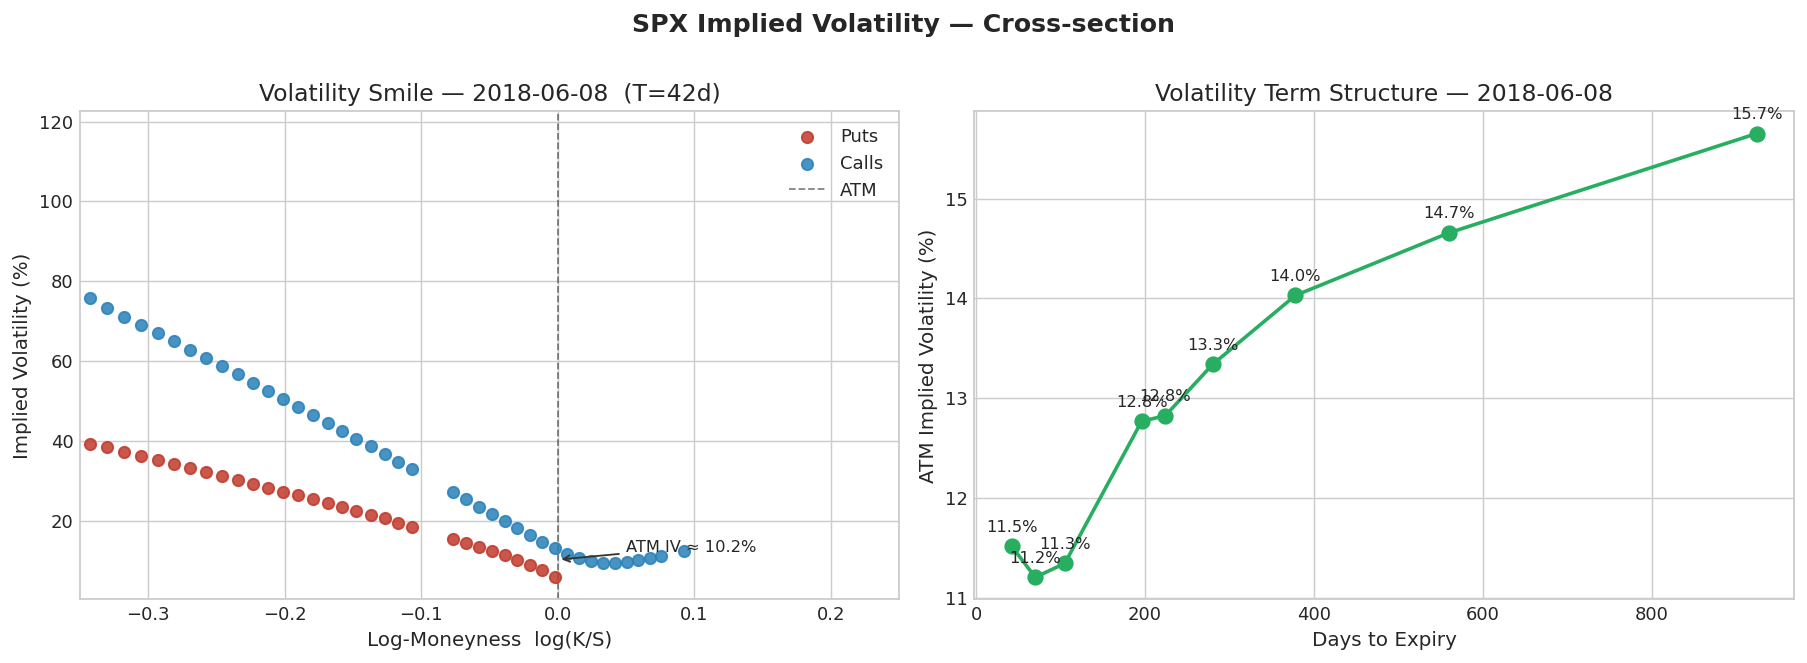

In [8]:
# ── Pick one representative date ──────────────────────────────────────────────
sample_date = pd.Timestamp('2018-06-08')   # change as needed
day_df = df[df['date'] == sample_date]

# Best expiry ~ TARGET_TENOR days
exp_options = day_df['exp_date'].unique()
best_exp    = exp_options[
    np.argmin(np.abs((pd.to_datetime(exp_options) - sample_date).days - TARGET_TENOR))
]
smile_df = day_df[day_df['exp_date'] == best_exp].sort_values('log_m')
T_actual = int((best_exp - sample_date).days)
print(f"Plotting smile for {sample_date.date()}  expiry={best_exp.date()}  T={T_actual}d")

# ── Figure ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Smile
ax = axes[0]
for opt_type, color, label in [('P','#c0392b','Puts'), ('C','#2980b9','Calls')]:
    sub = smile_df[smile_df['type'] == opt_type]
    ax.scatter(sub['log_m'], sub['iv']*100, color=color, s=40, alpha=0.85,
               label=label, zorder=3)
ax.axvline(0, color='#333', lw=1, ls='--', alpha=0.6, label='ATM')
atm_iv_val = smile_df[smile_df['log_m'].abs() < 0.01]['iv'].mean() * 100
ax.annotate(f'ATM IV ≈ {atm_iv_val:.1f}%', xy=(0, atm_iv_val),
            xytext=(0.05, atm_iv_val + 2), fontsize=9,
            arrowprops=dict(arrowstyle='->', color='#333', lw=1))
ax.set(xlabel='Log-Moneyness  log(K/S)', ylabel='Implied Volatility (%)',
       title=f'Volatility Smile — {sample_date.date()}  (T={T_actual}d)',
       xlim=(-0.35, 0.25))
ax.legend(fontsize=10)

# Right: Term structure of ATM IV
ts_rows = []
for exp in sorted(day_df['exp_date'].unique()):
    sub = day_df[(day_df['exp_date'] == exp) & (day_df['log_m'].abs() < 0.03)]
    if len(sub) > 0:
        ts_rows.append({'days': (exp - sample_date).days, 'atm_iv': sub['iv'].mean()*100})
ts = pd.DataFrame(ts_rows)
ax = axes[1]
ax.plot(ts['days'], ts['atm_iv'], 'o-', color='#27ae60', lw=2, ms=8)
for _, r in ts.iterrows():
    ax.annotate(f"{r['atm_iv']:.1f}%", (r['days'], r['atm_iv']),
                textcoords='offset points', xytext=(0, 8), fontsize=9, ha='center')
ax.set(xlabel='Days to Expiry', ylabel='ATM Implied Volatility (%)',
       title=f'Volatility Term Structure — {sample_date.date()}')

plt.suptitle('SPX Implied Volatility — Cross-section', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


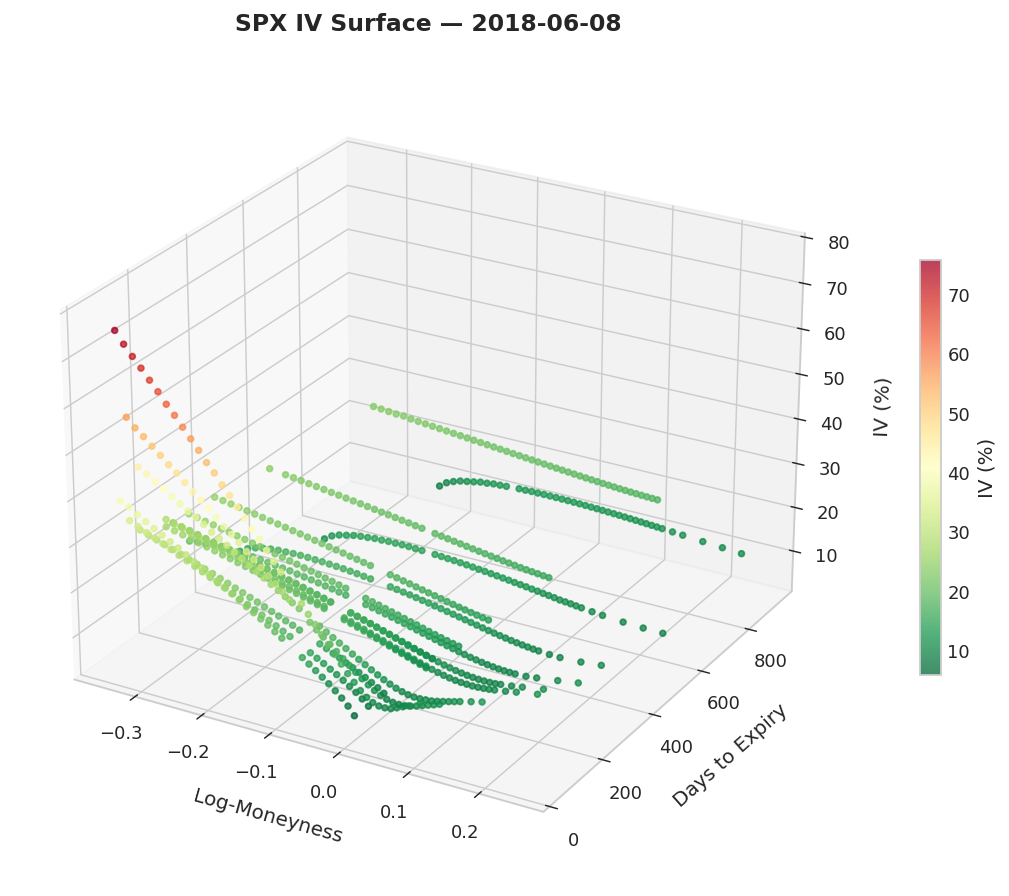

In [9]:
# ── 3-D volatility surface ─────────────────────────────────────────────────────
fig = plt.figure(figsize=(12, 7))
ax  = fig.add_subplot(111, projection='3d')
surf_df = day_df[(day_df['log_m'] > -0.35) & (day_df['log_m'] < 0.25)]
sc = ax.scatter(surf_df['log_m'], surf_df['T']*365, surf_df['iv']*100,
                c=surf_df['iv']*100, cmap='RdYlGn_r', s=10, alpha=0.75)
ax.set_xlabel('Log-Moneyness', labelpad=8)
ax.set_ylabel('Days to Expiry', labelpad=8)
ax.set_zlabel('IV (%)', labelpad=8)
ax.set_title(f'SPX IV Surface — {sample_date.date()}', fontweight='bold', pad=12)
plt.colorbar(sc, ax=ax, shrink=0.5, label='IV (%)')
ax.view_init(elev=25, azim=-60)
plt.tight_layout()
plt.show()


## 5 · Daily time-series: ATM IV (constant maturity), skew, convexity

### 5.1 The varying-tenor problem

A naive approach would select, each day, the expiry closest to the target tenor (30 days). This produces a **heterogeneous** $X_t$: the selected option may have 42 days to expiry one day and 20 days the next, with discrete jumps each time a new expiry becomes the nearest. Within a single expiry cycle the tenor drifts continuously downward, then jumps abruptly at each roll. Comparing a 42-day IV one day to a 20-day IV the next breaks the consistency of the regressor series $X_t$.



### 5.2 Solution: constant-maturity interpolation

We bracket the target tenor $\tau = 30$ days between the two available expiries $T_1 \leq \tau < T_2$ and interpolate **in variance** (linearly in $\sigma^2$, not in $\sigma$):

$$\sigma_{\tau}^2 = \frac{T_2 - \tau}{T_2 - T_1}\,\sigma_{T_1}^2 + \frac{\tau - T_1}{T_2 - T_1}\,\sigma_{T_2}^2$$

$$\sigma_{\tau} = \sqrt{\sigma_{\tau}^2}$$

Interpolation is performed in variance rather than volatility because variance is additive in time under Black-Scholes: $\sigma^2 T$ represents the expected integrated variance, and it is this quantity that scales linearly with $T$. This is exactly the methodology used by the **CBOE to compute the VIX**.

### 5.3 Extracted metrics

The same three metrics are computed for each of the two bracketing expiries and then interpolated separately:

$$\text{Skew}_t = \overline{\text{IV}}_{\text{put wing}} - \overline{\text{IV}}_{\text{call wing}}$$

$$\text{Convexity}_t = \frac{\overline{\text{IV}}_{\text{put wing}} + \overline{\text{IV}}_{\text{call wing}}}{2} - \text{ATM\_IV}_t$$

In [10]:
metrics = extract_daily_metrics(df, TARGET_TENOR, WING_LOW, WING_HIGH_PUT, WING_LOW_CALL, WING_HIGH)
metrics.head()

✓ Daily metrics: 253 trading days  (constant-maturity 30d interpolation)


,atm_iv,skew,convexity,iv_put_wing,iv_call_wing
date,,,,,
2017-06-08,0.085393,0.068379,0.046147,0.165730,0.097351
2017-06-09,0.083154,NaN,NaN,0.169154,NaN
2017-06-12,0.084561,0.074390,0.054408,0.176163,0.101773
2017-06-13,0.105945,0.068611,0.029695,0.169946,0.101334
2017-06-14,0.106155,0.064821,0.036631,0.175197,0.110375


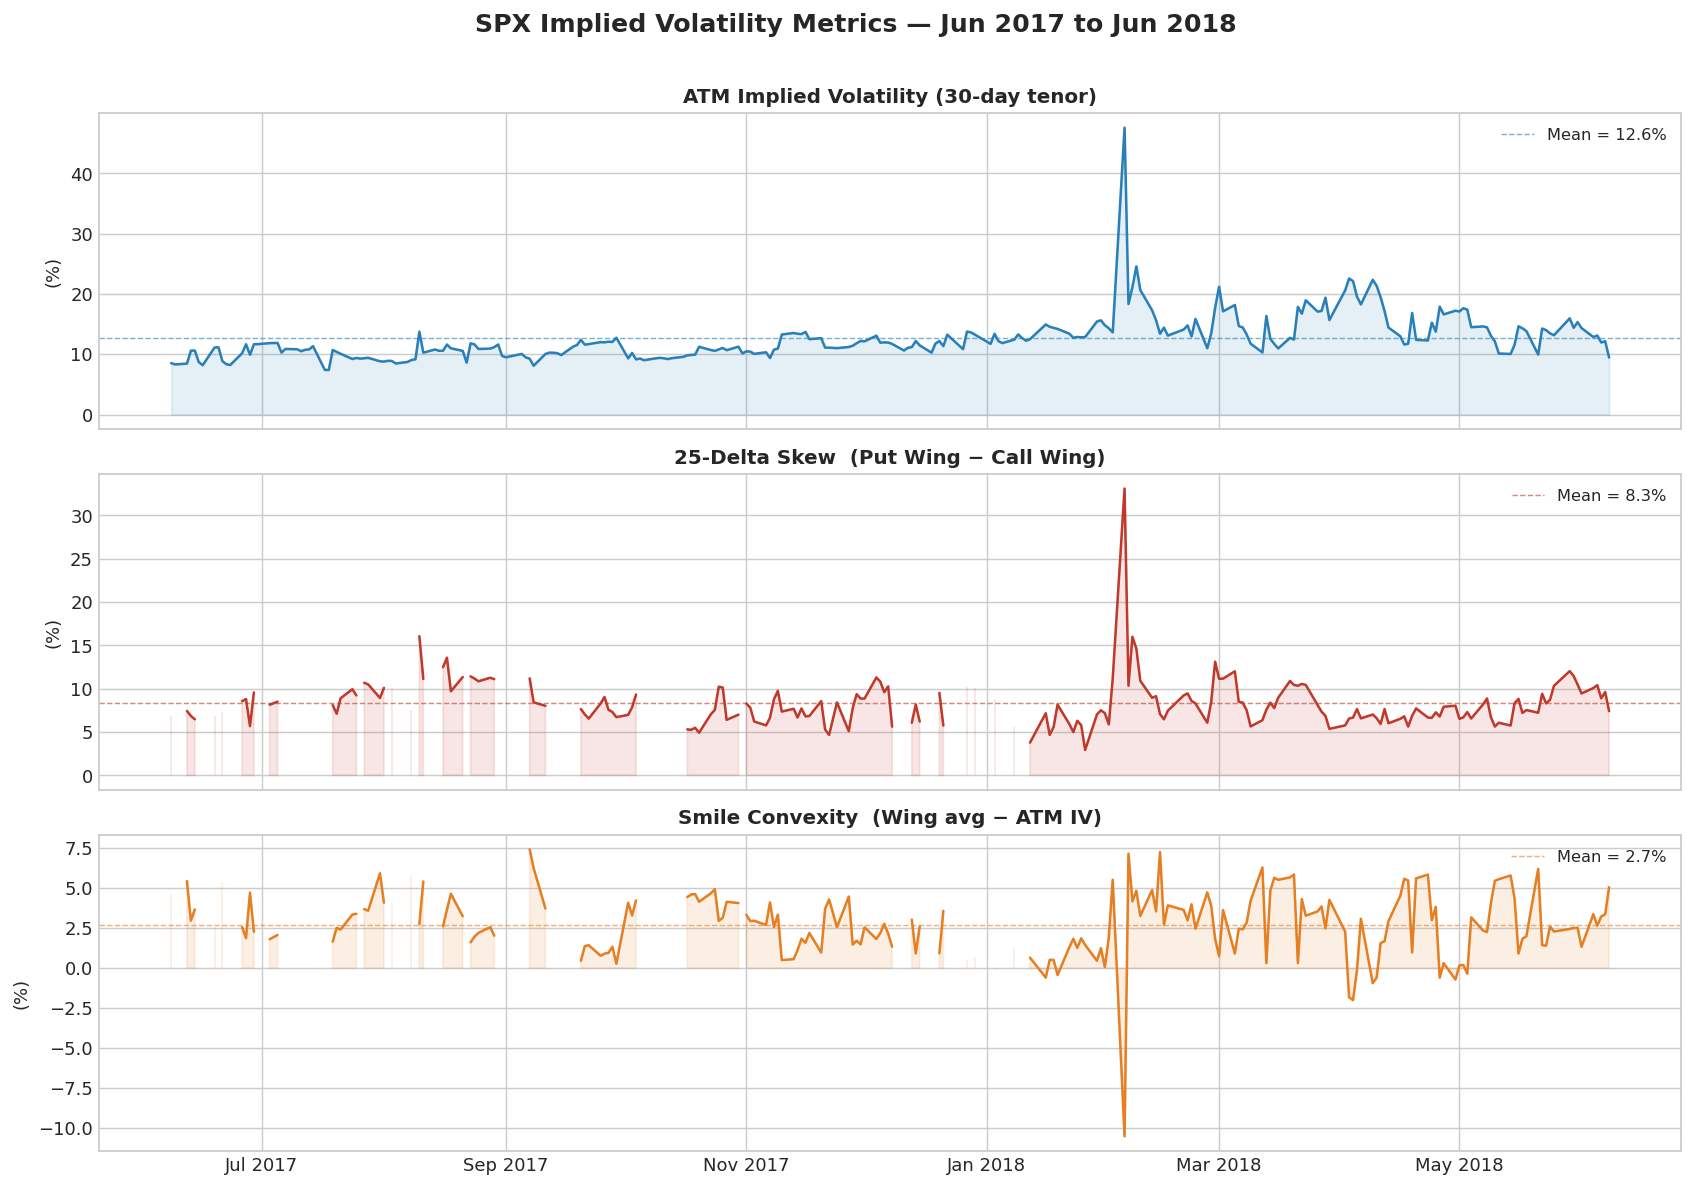

In [11]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
colors = ['#2980b9', '#c0392b', '#e67e22']
titles = ['ATM Implied Volatility (30-day tenor)',
          '25-Delta Skew  (Put Wing − Call Wing)',
          'Smile Convexity  (Wing avg − ATM IV)']
cols   = ['atm_iv', 'skew', 'convexity']

for ax, col, color, title in zip(axes, cols, colors, titles):
    y = metrics[col] * 100
    ax.plot(metrics.index, y, color=color, lw=1.4)
    ax.fill_between(metrics.index, y, alpha=0.12, color=color)
    ax.axhline(y.mean(), color=color, lw=0.8, ls='--', alpha=0.6,
               label=f'Mean = {y.mean():.1f}%')
    ax.set_ylabel('(%)', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9, loc='upper right')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.suptitle('SPX Implied Volatility Metrics — Jun 2017 to Jun 2018',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 6 · Realized volatility & Variance Risk Premium

**Realized volatility** (historical) over a rolling 21-day window:

$$RV_t = \sqrt{252} \cdot \hat\sigma\left(r_{t-20},\ldots,r_{t}\right), \quad r_t = \ln\frac{S_t}{S_{t-1}}$$

**Forward realized volatility** (what we want to predict):

$$RV^{\text{fwd}}_t = \sqrt{252} \cdot \hat\sigma\left(r_{t+1},\ldots,r_{t+21}\right)$$

**Variance Risk Premium**:

$$\text{VRP}_t = IV²_t - RV^{\text{fwd}}_t² \quad (\text{typically positive → investors overpay for vol protection})$$

### The overlapping window problem
The naive approach computes RV_forward by shifting one day at a time:
$RV^{fwd}_t$ uses returns $[t+1, ..., t+21]$ and $RV^{fwd}_{t+1}$ uses $[t+2, ..., t+22]$.
consecutive observations share 20 out of 21 days → MA(20) autocorrelation
in the residuals with $\hat{\rho}_1 \approx 0.875$ by construction.
OLS estimates remain unbiased but standard errors are invalid.

### Two solutions

| | Overlapping (HAC) | Non-overlapping |
|---|---|---|
| **Observations** | ~163 | ~12 |
| **Autocorrelation** | Structural MA(20) | None by construction |
| **Fix** | Newey-West (20 lags) | Not needed |
| **Cost** | Invalid raw SEs | Loss of statistical power |
| **Reference** | Newey-West (1987) | Hansen & Hodrick (1980) |

Both approaches use all 253 daily returns to compute RV windows.
The difference is only in which observation dates enter the regression.
Results are presented in parallel as a robustness check.

In [15]:
# Spot price
spot_ts = df.groupby('date')['spot'].median().sort_index()
log_ret = np.log(spot_ts / spot_ts.shift(1))

# ── Realized volatility (annualized) ──────────────────────────────────────────
rv_past    = log_ret.rolling(RV_WINDOW).std() * np.sqrt(252)          # backward
rv_forward = log_ret.shift(-RV_WINDOW).rolling(RV_WINDOW).std() * np.sqrt(252)  # forward (target)

# ── Daily variance proxy for HAR components (r_t² × 252) ──────────────────────
# Distinct from rv_past: instantaneous, not smoothed over a window.
# Used as the daily RV component in HAR-type models (Corsi, 2009).
rv_d_var = (log_ret ** 2) * 252

# ── APPROACH 1 : Overlapping windows ──────────────────────────────────────────
reg_overlap = metrics.copy()
reg_overlap['rv_past']    = rv_past.reindex(reg_overlap.index)
reg_overlap['rv_forward'] = rv_forward.reindex(reg_overlap.index)
reg_overlap['vrp']        = reg_overlap['atm_iv']**2 - reg_overlap['rv_forward']**2
reg_overlap = reg_overlap.dropna(subset=['atm_iv', 'rv_past', 'rv_forward'])

print(f"Overlapping   : N = {len(reg_overlap)} observations")

# ── APPROACH 2 : Non-overlapping windows (skip every 21 days) ─────────────────
reg_nonoverlap = reg_overlap.iloc[::RV_WINDOW].copy()

print(f"Non-overlapping : N = {len(reg_nonoverlap)} observations")

Overlapping   : N = 211 observations
Non-overlapping : N = 11 observations


=== Variance Risk Premium ===
Mean VRP (IV − RV_fwd) : -0.19%
Std  VRP               :  2.82%
% positive (IV > RV)   :  71.1%
Sample size            :  211 days


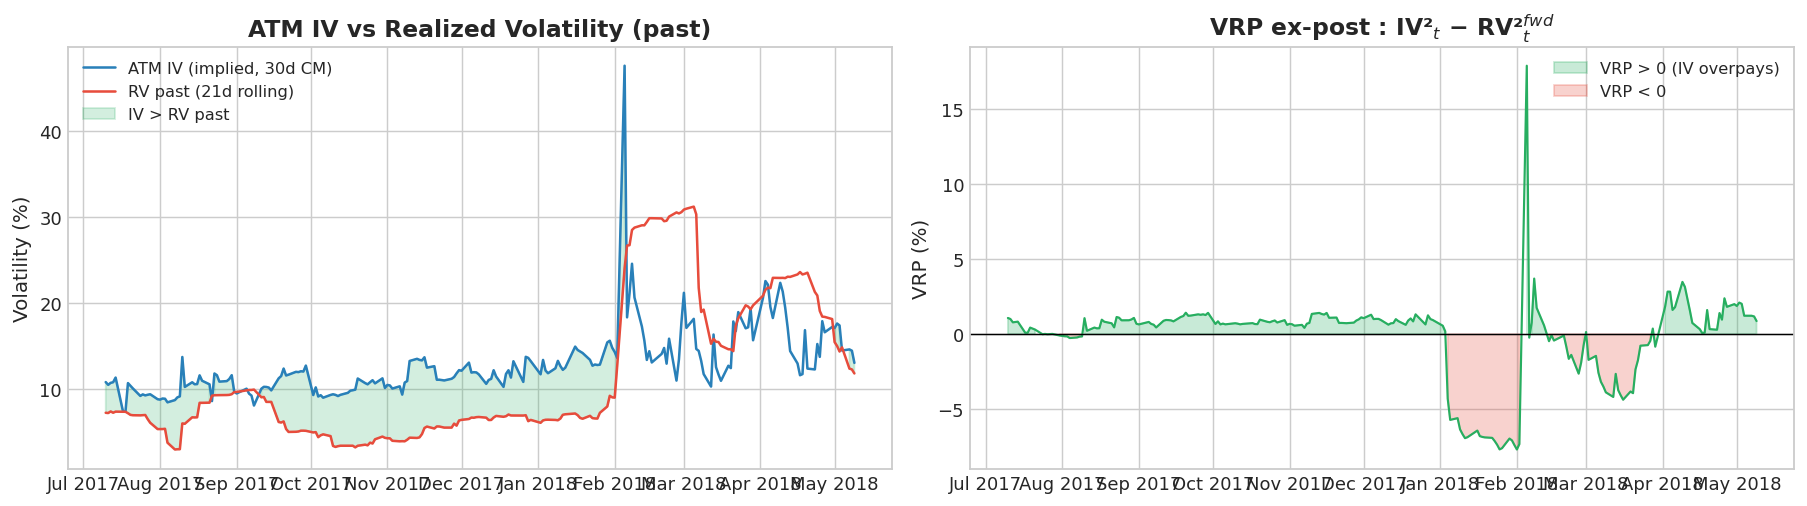

In [16]:
print("=== Variance Risk Premium ===")
print(f"Mean VRP (IV − RV_fwd) : {reg_overlap['vrp'].mean()*100:+.2f}%")
print(f"Std  VRP               :  {reg_overlap['vrp'].std()*100:.2f}%")
print(f"% positive (IV > RV)   :  {(reg_overlap['vrp']>0).mean()*100:.1f}%")
print(f"Sample size            :  {len(reg_overlap)} days")

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Panel A : contemporaneous IV vs rv_past — visual dynamics, not the VRP definition
ax = axes[0]
ax.plot(reg_overlap.index, reg_overlap['atm_iv']*100,  color='#2980b9', lw=1.4, label='ATM IV (implied, 30d CM)')
ax.plot(reg_overlap.index, reg_overlap['rv_past']*100, color='#e74c3c', lw=1.4, label='RV past (21d rolling)')
ax.fill_between(reg_overlap.index, reg_overlap['atm_iv']*100, reg_overlap['rv_past']*100,
                where=reg_overlap['atm_iv'] > reg_overlap['rv_past'],
                alpha=0.2, color='#27ae60', label='IV > RV past')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.set_ylabel('Volatility (%)')
ax.set_title('ATM IV vs Realized Volatility (past)', fontweight='bold')
ax.legend(fontsize=9)

# Panel B : VRP ex-post = IV_t − RV_forward_t
ax = axes[1]
ax.plot(reg_overlap.index, reg_overlap['vrp']*100, color='#27ae60', lw=1.2)
ax.axhline(0, color='black', lw=0.8)
ax.fill_between(reg_overlap.index, reg_overlap['vrp']*100, 0,
                where=reg_overlap['vrp']>0,  alpha=0.25, color='#27ae60', label='VRP > 0 (IV overpays)')
ax.fill_between(reg_overlap.index, reg_overlap['vrp']*100, 0,
                where=reg_overlap['vrp']<=0, alpha=0.25, color='#e74c3c', label='VRP < 0')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.set_ylabel('VRP (%)')
ax.set_title('VRP ex-post : IV²$_t$ − RV²$^{fwd}_t$', fontweight='bold')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


In [17]:
import pickle

ts_bundle = {
    'reg_overlap'    : reg_overlap,
    'reg_nonoverlap' : reg_nonoverlap,
    'spot_ts'        : spot_ts,
    'log_ret'        : log_ret,
    'rv_past'        : rv_past,
    'rv_forward'     : rv_forward,
    'rv_d_var'       : rv_d_var,       # r_t² × 252 — daily variance proxy for HAR components
    'metrics'        : metrics,
    'df'             : df
}

with open('time_series.pkl', 'wb') as f:
    pickle.dump(ts_bundle, f)

print("Saved : time_series.pkl")
print(f"  reg_overlap    : {len(reg_overlap)} obs")
print(f"  reg_nonoverlap : {len(reg_nonoverlap)} obs")



Saved : time_series.pkl
  reg_overlap    : 211 obs
  reg_nonoverlap : 11 obs
